In [41]:
import torch
from pytorch3d.io import load_obj
import pytorch3d.renderer
import pytorch3d.structures
from starter.utils import get_mesh_renderer
import matplotlib.pyplot as plt

In [47]:
# Load cow mesh

verts, faces, aux = load_obj("data/cow.obj")


In [48]:
# Spin up renderer and camera
renderer = get_mesh_renderer(image_size=512, device="cpu")
cameras = pytorch3d.renderer.FoVPerspectiveCameras(
    R=torch.eye(3).unsqueeze(0), # Camera w/ identity rotation
    T=torch.tensor([[0, 0, 3]]), # Placed 3 units from origin
    fov=60,
    device="cpu"
)
# Spin up light
lights = pytorch3d.renderer.PointLights(location=[[0, 0, -3]])

In [49]:
# Add 1 dimension to verts and faces for batching

verts = torch.unsqueeze(verts, 0)
faces = torch.unsqueeze(faces.verts_idx, 0)
# textures = torch.ones([1, verts.])



In [66]:
textures = torch.ones_like(verts) * torch.Tensor([0.3, 0.2, 0.8])

meshes = pytorch3d.structures.Meshes(

    verts=verts,
    faces=faces,
    textures=pytorch3d.renderer.TexturesVertex(textures),
    
)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

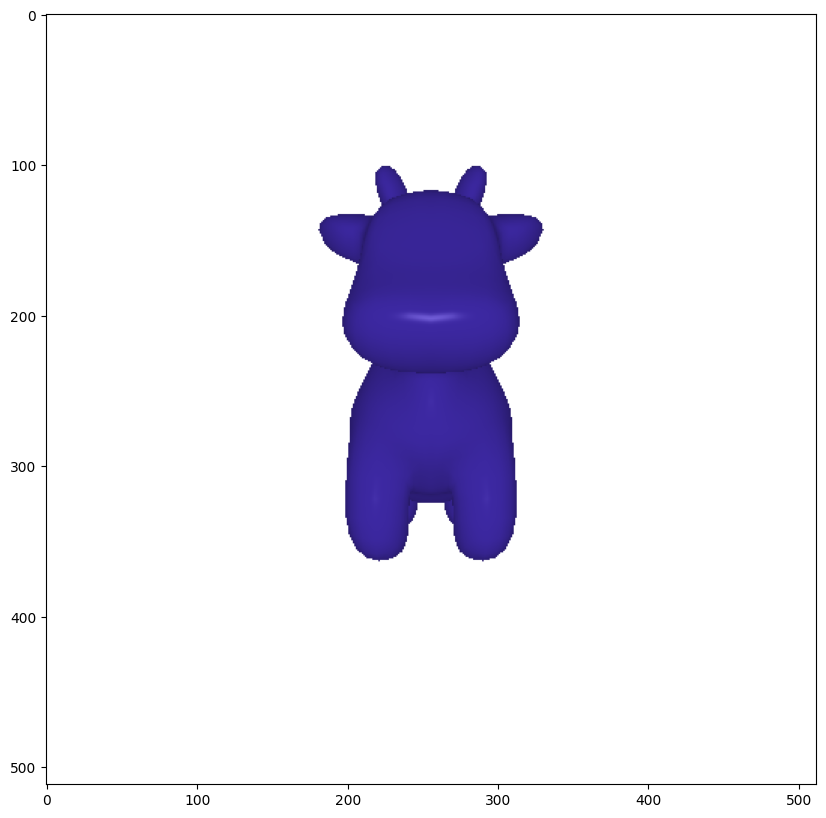

In [67]:
rend = renderer(meshes, cameras=cameras, lights=lights)

# render only the first image of the batch
plt.figure(figsize=(10, 10))
plt.imshow(rend[0, ..., :3])
plt.axes("off")
